# Unconstrained Optimization Theory

In this section, we examine the problem of minimizing a function of interest $f(x)$ without any constraints.
The unconstrained minimization problem takes the form

\begin{equation*}
\begin{aligned}
\text{minimize} \qquad & f(x) \\
\text{with respect to} \qquad & x \\
\end{aligned}
\end{equation*}

The function is defined over $\mathbb{R}^{n}$ such that $f : \mathbb{R}^{n} \rightarrow \mathbb{R}$.
We assume that the objective function is smooth, such that we can evaluate the gradient $\nabla f$ and the Hessian matrix $H(x)$ anywhere and they are well defined.

Not many practical engineering optimization problems are completely unconstrained.
Many problems require at least variable bounds, for instance, $x \ge 0$, or $l \le x \le u$.
Some optimization problems are highly constrained.
For instance, aircraft structural design problems often have $\mathcal{O}(10^4)$ loading conditions, each requiring their own set of constraints.

However, studying unconstrained optimization is useful because the optimization theory and algorithms for unconstrained optimization can aid in our understanding of the more complex algorithms required for constrained optimization.


## What is an optimal solution?

What constitutes a solution to an unconstrained minimization problem?
This is the key question answered by optimization theory.
First, we have to define what a solution is.

#### Global solution:
$x^{*}$ is a global minimizer if $f(x^{*}) \le f(x)$ for all $x$

A *global solution* is the lowest function value attained by $f$ anywhere.
Note that the function may take on its identical lowest value at multiple points, so the global solution may not be unique.
The global solution is difficult to find because we can only evaluate $f$, $\nabla f$ and $H$ locally, one point at a time.
It is therefore hard to know when to stop searching for a better point if you don't have additional information about the function.
For a general function, there is no local test that we can do that guarantees that we have the global solution.

Instead of seeking a global solution, we will often be satisfied if we can find a better design that is best in a neighbourhood of the optimized point.

#### Local solution:
$x^{*}$ is a local minimizer if $f(x^{*}) \le f(x)$ for all $x \in \mathcal{N}$

Most of the optimization algorithms that we'll look at in this course search for a local minimizer.
They search for a point $x^{*}$ that satisfies $f(x^{*}) \le f(x)$ for $x$ in a local neighbourhood of $x^{*}$.
This neighbourhood $\mathcal{N}$ is a non-empty set of points that surround $x^{*}$.

#### Convex functions

For a special class of functions, called convex functions, we do have a guarantee of global optimality.
A convex function satisfies the following inequality for any two points, $x$ and $y$:

\begin{equation*}
f(x + \theta (y - x)) \le (1 - \theta) f(x) + \theta f(y)
\end{equation*}

for any $\theta \in [0, 1]$.

There are a number of equivalent conditions to identify convex functions:

1. $f(y) \ge f(x) + (y - x)^{T} \nabla f(x)$ for any $x$ and $y$
2. $H(x) = \nabla^{2} f$ is positive semi-definite for all $x$

A few key properties of convex functions are:

1. Local optimality implies global optimality
2. Strict local optimality implies strict global optimality (replace inequalities with string inequalities for the definition of string local/global optima)
 
However, it can be difficult to identify if a function is convex; it requires special problem structure.
Many engineering problems are nonconvex.
In this course, we focus on nonconvex optimization.

## First and Second-order necessary conditions for unconstrained optimization

Necessary conditions answer the question: Given that we know $x^{*}$ is a local minimizer, what can we say about $\nabla f(x)$ and $H(x)$?
The first and second-order necessary conditions are stated in terms of the gradient and Hessian, respectively.

#### First-order necessary conditions
$x^{*}$ is a local minimizer $\implies \nabla f(x^{*}) = 0$

#### Second-order necessary conditions
$x^{*}$ is a local minimizer $\implies H(x^{*})$ is positive semi-definite 

$H(x)$ is positive semi-definite such that $p^{T} H p \ge 0$ for all $p \in \mathbb{R}^{n}$.

#### Proof:

At a local minimizer $x^{*}$, we construct an arbitrary search direction: $x(\alpha) = x^{*} + \alpha p$, where $p \in \mathbb{R}^{n}$ and $p \ne 0$.
  
Since $x^{*}$ is a local minimizer, along all directions we have:

1. $f(x(\alpha))$ has zero slope, and
2. $f(x(\alpha))$ has non-negative curvature.

From condition (1):

\begin{equation*}
\dfrac{df}{d\alpha} = \sum_{i=1}^{n} p_{i} \dfrac{\partial f}{\partial x_{i}} = p^{T}\nabla f(x^{*}) = 0
\end{equation*}

Since this must be true for any direction $p$, this implies $\nabla f(x^{*}) = 0$

From condition (2):

\begin{equation*}
\dfrac{d^2f}{d\alpha^2} = p^{T} H(x^{*}) p \ge 0
\end{equation*}

Again since $p$ is arbitrary, this implies $H(x^{*})$ is semi-definite.

## Second-order sufficient conditions for unconstrained optimization

Ideally, we would have sufficient conditions because we can evaluate $\nabla f$ and $H$ and use the conditions as a test.
This test would be definitive: find a new point $x$ that is an estimate of $x^{*}$, test whether $x$ satisfies the sufficient conditions, if it does stop, otherwise continue.
Sufficient conditions allow us to make a statement about $x$ (is it $x^{*}$?) given some $\nabla f(x)$ and $H(x)$.

#### Second-order sufficient conditions

$\nabla f(x^{*}) = 0$ and $H(x^{*})$ positive definite $\implies x^{*}$ is a local minimizer of $f(x)$.

$H(x)$ is positive definite such that $p^{T} H p > \alpha p^{T}p$ for all $p \in \mathbb{R}^{n}$.

#### Proof

Consider an arbitrary direction $p$ and expand $f(x^{*} + p)$ in a Taylor series expansion:

\begin{equation*}
\begin{aligned}
f(x^{*} + p) & = f(x^{*}) + p^{T} \nabla f(x^{*}) + \frac{1}{2} p^{T}H(x^{*} + \theta p)p \\
& = f(x^{*}) + \frac{1}{2} p^{T}H(x^{*} + \theta p)p
\end{aligned}
\end{equation*}

For some $\theta \in (0, 1)$ this is an equality due to the mean value theorem.
Since $p^{T}H(x^{*} + \theta p)p \ge \beta p^{T}p$ for some $\beta > 0$, then we have $f(x^{*} + p) > f(x^{*})$. So $x^{*}$ is a local minimizer of $f(x)$.

### Examples

These examples demonstrate both the first and second order necessary conditions as well as the second order sufficient conditions.

First, look at the contours of the following objective functions.
Note that this script demonstrates the use of function handles within Python.
You can pass functions as arguments so the same code can be re-used to generate the contour plots.

Some of these functions have minima, some have maxima, others have saddle points and others are unbounded without either minima or maxima.

\begin{equation*}
\begin{aligned}
f_{1}(x) &= x_{1}^2 + x_{2}^2 \\
f_{2}(x) &= x_{1}^2 - x_{2}^2 \\
f_{3}(x) &= x_{1}^2 + x_{2}^4 \\
f_{4}(x) &= x_{1}^2 - x_{2}^4 \\
f_{5}(x) &= x_{2}^2 \\
f_{6}(x) &= x_{1} + x_{2}^2 \\
f_{7}(x) &= 2x_{1}^2 + 2x_{1}x_{2} + \frac{1}{2}x_{2}^2 \\
f_{8}(x) &= 2x_{1}^2 + 2x_{1}x_{2} + \frac{1}{2}x_{2}^2 + 2x_{1} + x_{2} \\
f_{9}(x) &= 2x_{1}^2 + 2x_{1}x_{2} + \frac{1}{2}x_{2}^2 - x_{1} + 2x_{2} \\
f_{10}(x) &= 2x_{1}^2 + 2x_{1}x_{2} + x_{2}^2 - x_{1} + 2x_{2} \\
f_{11}(x) &= -x_{1}^2 -x_{2}^2 \\
f_{12}(x) &= -x_{1}^2 \\
\end{aligned}
\end{equation*}

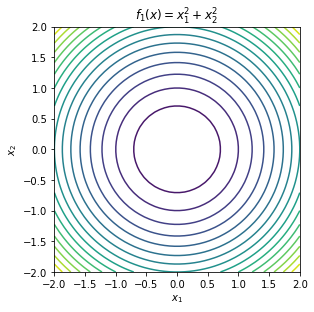

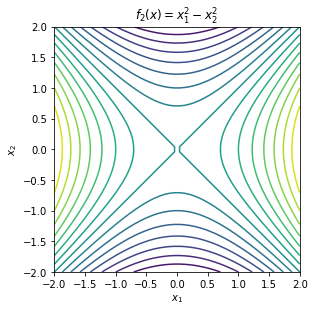

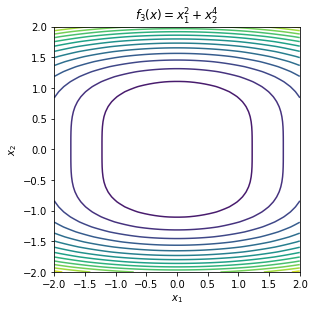

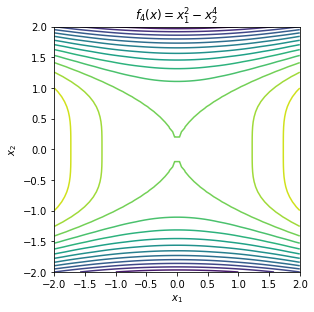

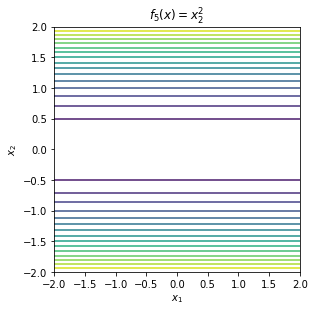

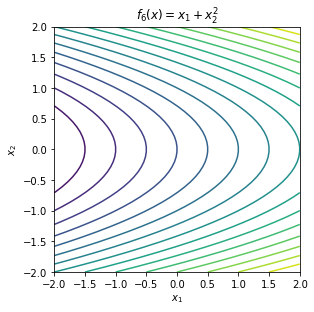

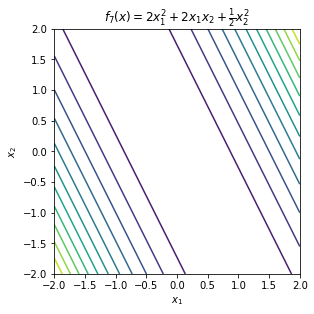

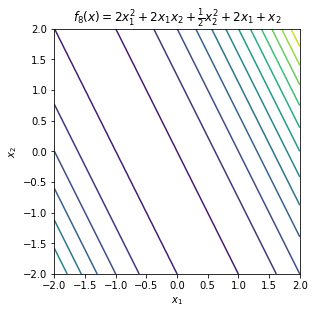

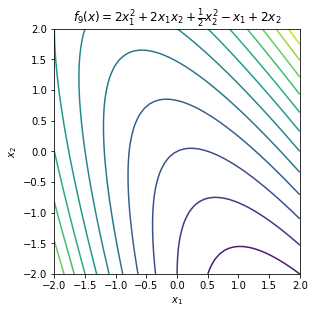

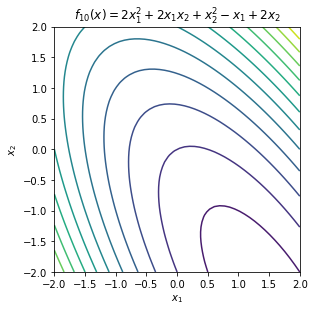

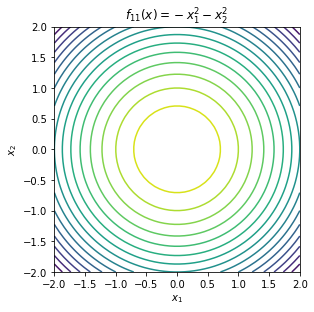

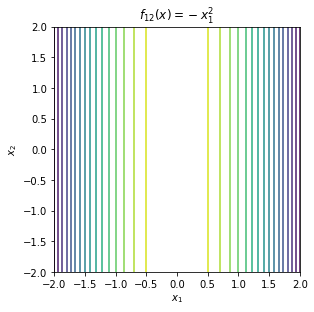

In [1]:
import numpy as np
import matplotlib.pylab as plt

def contour_plot(fobj, name=None, levels=15,
                 xmin=-2, xmax=2, ymin=-2, ymax=2):
    # Generate the data for a contour plot
    n = 50
    x1 = np.linspace(xmin, xmax, n)
    x2 = np.linspace(ymin, ymax, n)
    X1, X2 = np.meshgrid(x1, x2)
    f = np.zeros((n, n))

    # Query the function at the specified locations
    for i in range(n):
        for j in range(n):
            f[i, j] = fobj([X1[i, j], X2[i, j]])

    fig, ax = plt.subplots(1, 1)
    ax.contour(X1, X2, f, levels=levels)
    ax.set_aspect('equal', 'box')
    fig.tight_layout()
    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    if name is not None:
        plt.title(name)
    
    return

def f1(x):
    return x[0]**2 + x[1]**2

def f2(x):
    return x[0]**2 - x[1]**2

def f3(x):
    return x[0]**2 + x[1]**4

def f4(x):
    return x[0]**2 - x[1]**4

def f5(x):
    return x[1]**2

def f6(x):
    return x[0] + x[1]**2

def f7(x):
    return 2*x[0]**2 + 2*x[0]*x[1] + 0.5*x[1]**2

def f8(x):
    return 2*x[0]**2 + 2*x[0]*x[1] + 0.5*x[1]**2 + 2*x[0] + x[1]

def f9(x):
    return 2*x[0]**2 + 2*x[0]*x[1] + 0.5*x[1]**2 - x[0] + 2*x[1]

def f10(x):
    return 2*x[0]**2 + 2*x[0]*x[1] + x[1]**2 - x[0] + 2*x[1]

def f11(x):
    return -x[0]**2 -x[1]**2

def f12(x):
    return -x[0]**2

func_names = [
    r'$f_{1}(x) = x_{1}^2 + x_{2}^2$',
    r'$f_{2}(x) = x_{1}^2 - x_{2}^2$',
    r'$f_{3}(x) = x_{1}^2 + x_{2}^4$',
    r'$f_{4}(x) = x_{1}^2 - x_{2}^4$',
    r'$f_{5}(x) = x_{2}^2$',
    r'$f_{6}(x) = x_{1} + x_{2}^2$',
    r'$f_{7}(x) = 2x_{1}^2 + 2x_{1}x_{2} + \frac{1}{2}x_{2}^2$',
    r'$f_{8}(x) = 2x_{1}^2 + 2x_{1}x_{2} + \frac{1}{2}x_{2}^2 + 2x_{1} + x_{2}$',
    r'$f_{9}(x) = 2x_{1}^2 + 2x_{1}x_{2} + \frac{1}{2}x_{2}^2 - x_{1} + 2x_{2}$',
    r'$f_{10}(x) = 2x_{1}^2 + 2x_{1}x_{2} + x_{2}^2 - x_{1} + 2x_{2}$',
    r'$f_{11}(x) = -x_{1}^2 -x_{2}^2$',
    r'$f_{12}(x) = -x_{1}^2$']
funcs = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11, f12]

for fobj, name in zip(funcs, func_names):
    contour_plot(fobj, name)
    
plt.show()

To test the first and second order necessary conditions and the second order sufficient conditions, we need to compute the gradient and Hessian of the function of interest. Here we will use finite-different methods to compute approximations. This is not always advisable for these simple functions since numerical errors enter and the gradient and Hessian approximations. 

In [2]:
def approx_gradient(x, fobj, h=1e-6):
    '''Approximate the gradient using central difference'''
    x = np.array(x)
    e1 = np.array([1, 0])
    e2 = np.array([0, 1])
    g = np.array([0.5*(fobj(x + h*e1) - fobj(x - h*e1))/h,
                  0.5*(fobj(x + h*e2) - fobj(x - h*e2))/h])
    return g

def approx_hessian(x, fobj, h=1e-6):
    '''Approximate the Hessian'''
    x = np.array(x)
    e1 = np.array([1, 0])
    e2 = np.array([0, 1])
    H = np.array([[(fobj(x + h*e1) - 2*fobj(x) + fobj(x - h*e1))/h**2,
                   0.25*(fobj(x + h*(e1 + e2)) -
                         fobj(x + h*(e1 - e2)) -
                         fobj(x + h*(e2 - e1)) + 
                         fobj(x + h*(e1 + e2)))/h**2],
                  [0, (fobj(x + h*e2) - 2*fobj(x) + fobj(x - h*e2))/h**2]])
    H[1,0] = H[0,1]
    return H

x0 = [0, 0]
for index, fobj in enumerate(funcs):
    print('Testing function %d at the point '%(index), x0)
    g = approx_gradient(x0, fobj)
    
    if np.sqrt(np.dot(g, g)) < 1e-4:
        print('First-order necessary condition satisfied for ', fobj)
        
        H = approx_hessian(x0, fobj)
        eig, Q = np.linalg.eigh(H)
        
        print('Eigenvalues: ', eig)
        if eig[0] > 1e-4:
            print('Second order sufficient conditions satisfied for ', fobj)
        elif eig[0] < -1e-4:
            print('Second order sufficient conditions violated for ', fobj)
        else:
            print('Indefinite or numerical problems? ', eig[0])
    else:
        print('First-order necessary condition *violated* for ', fobj)
    
    print('')

Testing function 0 at the point  [0, 0]
First-order necessary condition satisfied for  <function f1 at 0x000001553D371430>
Eigenvalues:  [2. 2.]
Second order sufficient conditions satisfied for  <function f1 at 0x000001553D371430>

Testing function 1 at the point  [0, 0]
First-order necessary condition satisfied for  <function f2 at 0x000001553D3714C0>
Eigenvalues:  [-2.  2.]
Second order sufficient conditions violated for  <function f2 at 0x000001553D3714C0>

Testing function 2 at the point  [0, 0]
First-order necessary condition satisfied for  <function f3 at 0x000001553D371550>
Eigenvalues:  [2.e-12 2.e+00]
Indefinite or numerical problems?  1.9999999999999996e-12

Testing function 3 at the point  [0, 0]
First-order necessary condition satisfied for  <function f4 at 0x000001553D3715E0>
Eigenvalues:  [-2.e-12  2.e+00]
Indefinite or numerical problems?  -1.9999999999999996e-12

Testing function 4 at the point  [0, 0]
First-order necessary condition satisfied for  <function f5 at 0x000

## Using Unconstrained Optimization Theory

To use constrained optimization theory for simple problems, we can use the following steps:

1. Determine the gradient, $\nabla f(x)$ and Hessian matrix $H(x)$ via differentiation.
2. Solve the equation $\nabla f(x_{cr}) = 0$ for candidate points $x_{cr}$.
3. Evaluate the Hessian matrix $H(x_{cr})$ and determine whether it is positive definite, semi-definite, indefinite or negative.

#### Example 1

Consider the function

\begin{equation*}
f(x) = x_{1}^4 + x_{2}^4 - x_{1}^2 - x_{2}^2 + 2x_{1}x_{2}
\end{equation*}

The gradient of the function is

\begin{equation*}
\nabla f(x) = 
\begin{bmatrix}
4 x_{1}^3 - 2 x_{1} + 2 x_{2} \\
4 x_{2}^3 - 2 x_{2} + 2 x_{1} \\
\end{bmatrix}
\end{equation*}

The critical points are

\begin{equation*}
x_{cr} = \begin{bmatrix} 0 \\ 0 \end{bmatrix} \qquad
x_{cr} = \begin{bmatrix} 1 \\ -1 \end{bmatrix} \qquad
x_{cr} = \begin{bmatrix} -1 \\ 1 \end{bmatrix} \qquad
\end{equation*}

The Hessian matrix is

\begin{equation*}
H(x) = \begin{bmatrix}
12 x_{1}^2 - 2 & 2 \\
2 & 12 x_{2}^2 - 2 \\
\end{bmatrix}
\end{equation*}

For the point $x_{cr} = (0, 0)$, the Hessian matrix is

\begin{equation*}
H(x_{cr}) = \begin{bmatrix} -2 & 2 \\ 2 & -2 \end{bmatrix}
\end{equation*}

The eigenvalues of this matrix are $\lambda_{1} = -4$, $\lambda_{2} = 0$. As a result, this is not a local minima.

For the point $x_{cr} = (1, -1)$, the Hessian matrix is

\begin{equation*}
H(x) = \begin{bmatrix}
10 & 2 \\
2 & 10 \\
\end{bmatrix}
\end{equation*}

The eigenvalues are $\lambda_{1} = 8$, $\lambda_{2} = 12$, therefore the Hessian matrix is positive definite and this critical point is a local minimzier.

For the point $x_{cr} = (-1, 1)$, the Hessian matrix is

\begin{equation*}
H(x) = \begin{bmatrix}
10 & 2 \\
2 & 10 \\
\end{bmatrix}
\end{equation*}

The eigenvalues are again $\lambda_{1} = 8$, $\lambda_{2} = 12$, therefore the Hessian matrix is positive definite and this critical point is a local minimzier.

#### Example 2

Consider the function

\begin{equation*}
f(x) = x_{1}^{4} + x_{2}^{4} - x_{1}^2 + 2 x_{1}
\end{equation*}

The gradient of the function is

\begin{equation*}
\nabla f(x) = \begin{bmatrix}
4 x_{1}^3 - 2 x_{1} + 2 \\
4 x_{2}^3
\end{bmatrix}
\end{equation*}

A critical point is

\begin{equation*}
x_{cr} = \begin{bmatrix} -1 \\ 0 \end{bmatrix}
\end{equation*}

The Hessian matrix is

\begin{equation*}
H(x) = \begin{bmatrix}
12 x_{1}^{2} - 2 & 0 \\ 0 & 12 x_{2}^2 \\
\end{bmatrix}
\end{equation*}

At the critical point the Hessian matrix is

\begin{equation*}
H(x_{cr}) = \begin{bmatrix}
10 & 0 \\ 0 & 0 \\
\end{bmatrix}
\end{equation*}

This point satisfies the first and second order necessary conditions, but *not* the second order sufficient conditions. 
But, note that for $x = x_{cr} + (0, \epsilon)$, a small perturbation about $x_{2}$, the Hessian matrix will be 

\begin{equation*}
H(x_{cr}) = \begin{bmatrix}
10 & 0 \\ 0 & 12 \epsilon^2 \\
\end{bmatrix}
\end{equation*}

Therefore, the Hessian is positive definite close to the critical point. This suggests that we have a local minimizer, but since the theory we developed only uses a point-wise value of the Hessian, we can't confirm that it is a local minimizer based on $H(x_{cr})$ alone.

#### Example 3

Consider the function

\begin{equation*}
f(x) = x_{1}^4 + 4 x_{1}^3 x_{2} + 6 x_{1}^2 x_{2}^2 - x_{2}^2 + 4 x_{1} x_{2}^3 - 6 x_{1} x_{2} + x_{2}^{4} - x_{2}^2
\end{equation*}

The gradient of the function is

\begin{equation*}
\nabla f = \begin{bmatrix}
4 x_{1}^3 + 12 x_{1}^2 x_{2} + 12 x_{1} x_{2}^2 + 4 x_{2}^3 - 2 x_{1} - 6 x_{2} \\
4 x_{1}^3 + 12 x_{1}^2 x_{2} + 12 x_{1}^2 x_{2} + 4 x_{2}^3 - 6 x_{1} - 2 x_{2}
\end{bmatrix}
\end{equation*}

The critical points, where $\nabla f(x_{cr}) = 0$, are:

\begin{equation*}
x_{cr} = \begin{bmatrix}
0 \\ 0
\end{bmatrix} \qquad
x_{cr} = \dfrac{1}{2} \begin{bmatrix}
1 \\ 1
\end{bmatrix} \qquad
x_{cr} = \dfrac{1}{2} \begin{bmatrix}
-1 \\ -1
\end{bmatrix}
\end{equation*}

The Hessian matrix is

\begin{equation*}
H(x) = \begin{bmatrix}
12(x_{1}^2 + 2 x_{1}x_{2} + x_{2}^2) - 2 & 12(x_{1}^2 + 2 x_{1}x_{2} + x_{2}^2) - 6 \\
12(x_{1}^2 + 2 x_{1}x_{2} + x_{2}^2) - 6 & 12(x_{1}^2 + 2 x_{1}x_{2} + x_{2}^2) - 2 \\
\end{bmatrix}
\end{equation*}

For $x_{cr} = (0, 0)$ the Hessian matrix is

\begin{equation*}
H(x_{cr}) = \begin{bmatrix}
-2 & -6 \\
-6 & -2 \\
\end{bmatrix}
\end{equation*}

The eigenvalues of this matrix are $\lambda_{1} = -8$ and $\lambda_{2} = 4$.
Therefore, this is a saddle point.

For the point $x_{cr} = (1/2, 1/2)$ the Hessian matrix is

\begin{equation*}
H(x_{cr}) = \begin{bmatrix}
10 & 6 \\
6 & 10 \\
\end{bmatrix}
\end{equation*}

The eigenvalues of this matrix are $\lambda_{1} = 4$ and $\lambda_{2} = 16$. This is positive definite. Since $\nabla f(x_{cr}) = 0$ and $H(x_{cr})$ is positive definite, the second order sufficient conditions hold and this is a local minimizer.

For the point $x_{cr} = (-1/2, -1/2)$ the Hessian matrix is again

\begin{equation*}
H(x_{cr}) = \begin{bmatrix}
10 & 6 \\
6 & 10 \\
\end{bmatrix}
\end{equation*}

As before, the eigenvalues of this matrix are $\lambda_{1} = 4$ and $\lambda_{2} = 16$. Since this is positive definite and $\nabla f(x_{cr}) = 0$, the second order sufficient conditions hold again and this is a local minimizer.

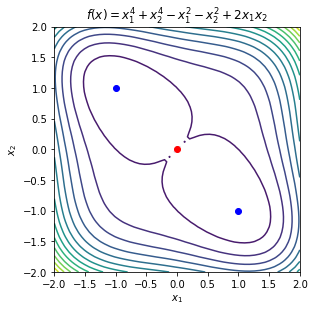

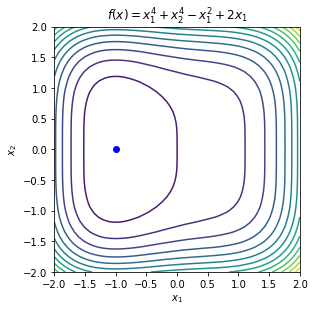

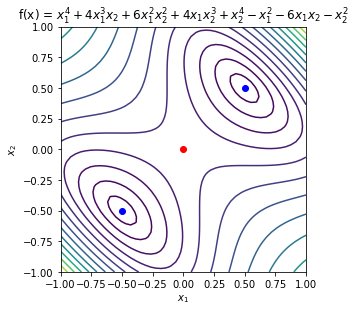

In [3]:
name = r'$f(x) = x_{1}^4 + x_{2}^4 - x_{1}^2 - x_{2}^2 + 2x_{1}x_{2}$'
def f(x):
    return x[0]**4 + x[1]**4 - x[0]**2 - x[1]**2 + 2*x[0]*x[1]

contour_plot(f, name=name)
plt.plot([0], [0], 'ro')
plt.plot([1], [-1], 'bo')
plt.plot([-1], [1], 'bo')

name = r'$f(x) = x_{1}^{4} + x_{2}^{4} - x_{1}^2 + 2 x_{1}$'
def f(x):
     return x[0]**4 + x[1]**4 - x[0]**2 + 2 * x[0]
    
contour_plot(f, name=name)
plt.plot([-1], [0], 'bo')

name = r'f(x) = $x_{1}^4 + 4 x_{1}^3 x_{2} + 6 x_{1}^2 x_{2}^2 + '
name += r'4 x_{1} x_{2}^3 + x_{2}^{4} - x_{1}^2 - 6 x_{1} x_{2} - x_{2}^2$'
def f(x):
    return (x[0]**4 + 4 * x[0]**3 * x[1] + 6 * x[0]**2 * x[1]**2
            + 4 * x[0] * x[1]**3 + x[1]**4
            - x[0]**2 - 6 * x[0] * x[1] - x[1]**2)

fmin = -1.0
fmax = 8.0
levels = fmin + (fmax - fmin)*np.linspace(0, 1, 15)**2
contour_plot(f, name=name, levels=levels, xmin=-1, xmax=1, ymin=-1, ymax=1)
plt.plot([0.5], [0.5], 'bo')
plt.plot([-0.5], [-0.5], 'bo')
plt.plot([0], [0], 'ro')

plt.show()

## Live Demo of Unconstrained Optimization

The applet below serves as a way to interactively explore unconstrained optimization using GeoGebra. To interact with the applet, drag the orange dot around on the 2D graph, and watch as the gradient direction dynamically updates. For a better viewing experience, you can open the applet in full-screen mode.

In [4]:
from IPython.display import HTML

html_code = """
<script src="https://www.geogebra.org/apps/deployggb.js"></script>
<script>
var params = {"material_id": "ww2g6esc", "showFullScreenButton": true};
var applet = new GGBApplet(params, true);
window.addEventListener("load", function() {
    applet.inject('ggb-element');
});
</script>
<div id="ggb-element"></div>
"""

HTML(html_code)